# NB09B — EBM Ensemble Extension

**Purpose:** Extend the NB09A ensemble analysis to incorporate EBM (M2.5)
as the primary ensemble partner, replacing the original M2-matched + M3 design.
EBM is the best-performing single model at both stages — its inclusion in
the ensemble tests whether further gains are achievable through averaging.

## Ensemble specifications

| Label | Models averaged | Rationale | Status |
|-------|----------------|-----------|--------|
| **E1-EBM** | M2-matched + EBM M2.5 | Primary: two models, same features, complementary algorithms | **Primary result** |
| **E2-EBM** | EBM M2.5 + M3 | Interpretable + sentiment: tests whether sentiment adds over EBM | Secondary |
| **E3-Full** | M2-matched + EBM + M3 | Three-way average: maximum diversity | Exploratory |
| E1-Original | M2-matched + M3 | Original NB09A result — retained for comparison | Reference |

## Notebook dependency chain
```
NB05A → NB05B → NB06B → NB07B → NB08B → NB09B  (this notebook)
```

**Inputs:**
- `oos_predictions_stage2.csv` (NB05A: M2-matched, M3)
- `oos_predictions_stage2_ebm.csv` (NB05B: EBM M2.5)

**Outputs:**
- `oos_predictions_ensemble_ebm.csv`
- `figures/augmented_analysis/nb09b_ensemble_roc_pr.png`
- `figures/augmented_analysis/nb09b_ensemble_disagreement.png`
- `figures/augmented_analysis/nb09b_2007_country_ranking.png`

---

## Cell 1 — Imports and paths

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.utils import resample

BASE    = Path(r'C:\Users\Owner\OneDrive\dissertation')
OUT_DIR = BASE / 'data' / 'processed' / 'augmented_analysis'
FIG_DIR = BASE / 'figures' / 'augmented_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET       = 'target_h2'
RANDOM_STATE = 42
N_BOOTSTRAP  = 1000

# Verify inputs
required = [
    OUT_DIR / 'oos_predictions_stage2.csv',
    OUT_DIR / 'oos_predictions_stage2_ebm.csv',
]
print('Input file check:')
all_ok = True
for f in required:
    ok = f.exists()
    print(f'  {"✅" if ok else "❌ MISSING"}  {f.name}')
    if not ok: all_ok = False
if not all_ok:
    raise FileNotFoundError('Missing inputs. Run NB05A and NB05B first.')

print()
print('=' * 65)
print(' NB09B — EBM ENSEMBLE EXTENSION')
print('=' * 65)

Input file check:
  ✅  oos_predictions_stage2.csv
  ✅  oos_predictions_stage2_ebm.csv

 NB09B — EBM ENSEMBLE EXTENSION


## Cell 2 — Load OOS predictions

In [2]:
s2      = pd.read_csv(OUT_DIR / 'oos_predictions_stage2.csv')
s2_ebm  = pd.read_csv(OUT_DIR / 'oos_predictions_stage2_ebm.csv')

# Drop burn-in NaN rows
s2_eval     = s2.dropna(subset=['prob_m2m', 'prob_m3']).copy()
s2_ebm_eval = s2_ebm.dropna(subset=['prob_ebm']).copy()

# Merge on year + iso for three-way comparison
combined = pd.merge(
    s2_eval[['year', 'iso', TARGET, 'prob_m2m', 'prob_m3']],
    s2_ebm_eval[['year', 'iso', 'prob_ebm']],
    on=['year', 'iso'], how='inner'
).dropna(subset=['prob_m2m', 'prob_m3', 'prob_ebm'])

print(f'Stage 2 OOS (after merge):')
print(f'  Rows         : {len(combined)}')
print(f'  Crisis events: {int(combined[TARGET].sum())}  '
      f'(base rate {combined[TARGET].mean():.4f})')
print(f'  Eval years   : {combined["year"].min():.0f}–{combined["year"].max():.0f}')
print()
print('Probability summary:')
print(combined[['prob_m2m','prob_ebm','prob_m3']].describe().round(4).to_string())

Stage 2 OOS (after merge):
  Rows         : 215
  Crisis events: 11  (base rate 0.0512)
  Eval years   : 2007–2018

Probability summary:
       prob_m2m  prob_ebm   prob_m3
count  215.0000  215.0000  215.0000
mean     0.1777    0.1230    0.1665
std      0.1727    0.2889    0.2126
min      0.0049    0.0000    0.0000
25%      0.0557    0.0000    0.0356
50%      0.1067    0.0003    0.0889
75%      0.2356    0.0096    0.1786
max      0.7377    0.9985    1.0000


## Cell 3 — Build all ensemble specifications

In [3]:
# ── All four ensemble variants ─────────────────────────────────────────────
combined['prob_e1_ebm']  = (combined['prob_m2m'] + combined['prob_ebm']) / 2
combined['prob_e2_ebm']  = (combined['prob_ebm'] + combined['prob_m3'])  / 2
combined['prob_e3_full'] = (combined['prob_m2m'] + combined['prob_ebm'] + combined['prob_m3']) / 3
combined['prob_e1_orig'] = (combined['prob_m2m'] + combined['prob_m3']) / 2

print('Ensemble specifications built:')
specs = [
    ('E1-EBM  (M2-matched + EBM)',          'prob_e1_ebm'),
    ('E2-EBM  (EBM + M3)',                  'prob_e2_ebm'),
    ('E3-Full (M2-matched + EBM + M3)',      'prob_e3_full'),
    ('E1-Orig (M2-matched + M3) [NB09A ref]','prob_e1_orig'),
]
for name, col in specs:
    print(f'  {name}: mean prob={combined[col].mean():.4f}')

Ensemble specifications built:
  E1-EBM  (M2-matched + EBM): mean prob=0.1503
  E2-EBM  (EBM + M3): mean prob=0.1447
  E3-Full (M2-matched + EBM + M3): mean prob=0.1557
  E1-Orig (M2-matched + M3) [NB09A ref]: mean prob=0.1721


## Cell 4 — Bootstrap metrics helper

In [4]:
def compute_metrics(y_true, y_prob, label, n_boot=N_BOOTSTRAP, seed=RANDOM_STATE):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    auroc  = roc_auc_score(y_true, y_prob)
    auprc  = average_precision_score(y_true, y_prob)
    brier  = brier_score_loss(y_true, y_prob)
    base   = y_true.mean()
    rng    = np.random.default_rng(seed)
    n      = len(y_true)
    boot_auroc, boot_auprc = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yb, pb = y_true[idx], y_prob[idx]
        if yb.sum() == 0 or yb.sum() == len(yb): continue
        boot_auroc.append(roc_auc_score(yb, pb))
        boot_auprc.append(average_precision_score(yb, pb))
    ci_a = (np.percentile(boot_auroc, 2.5), np.percentile(boot_auroc, 97.5))
    ci_p = (np.percentile(boot_auprc, 2.5), np.percentile(boot_auprc, 97.5))
    return {'Label': label,
            'AUROC': auroc, 'AUROC_lo': ci_a[0], 'AUROC_hi': ci_a[1],
            'AUPRC': auprc, 'AUPRC_lo': ci_p[0], 'AUPRC_hi': ci_p[1],
            'Brier': brier, 'Base_rate': base, 'AUPRC_lift': auprc/base}

print(f'Metric helper ready. Bootstrap resamples: {N_BOOTSTRAP}')

Metric helper ready. Bootstrap resamples: 1000


## Cell 5 — Primary results table: all models and ensembles

In [5]:
y = combined[TARGET].values

all_results = [
    compute_metrics(y, combined['prob_m2m'].values,   'M2-matched RF'),
    compute_metrics(y, combined['prob_ebm'].values,   'EBM M2.5-matched'),
    compute_metrics(y, combined['prob_m3'].values,    'M3 XGB+FinBERT'),
    compute_metrics(y, combined['prob_e1_ebm'].values, 'E1-EBM: avg(M2-matched, EBM)'),
    compute_metrics(y, combined['prob_e2_ebm'].values, 'E2-EBM: avg(EBM, M3)'),
    compute_metrics(y, combined['prob_e3_full'].values,'E3-Full: avg(M2m, EBM, M3)'),
    compute_metrics(y, combined['prob_e1_orig'].values,'E1-Orig: avg(M2m, M3) [NB09A ref]'),
]
results_df = pd.DataFrame(all_results)

w = 112
print('=' * w)
print(' NB09B — FULL ENSEMBLE RESULTS (Stage 2, 2003–2020)')
print(f' Obs: {len(combined)}  |  Crisis: {int(y.sum())}  |  Base rate: {y.mean():.4f}')
print('=' * w)
print(f' {"Model":<45} {"AUROC":>7} {"95% CI":>14} {"AUPRC":>7} {"95% CI":>14} {"Brier":>7} {"Lift":>5}')
print('-' * w)
for _, r in results_df.iterrows():
    tag = ' ← PRIMARY' if 'E1-EBM' in r.Label else (' ← NB09A ref' if 'Orig' in r.Label else '')
    print(f' {r.Label:<45} {r.AUROC:>7.4f} [{r.AUROC_lo:.3f},{r.AUROC_hi:.3f}] '
          f'{r.AUPRC:>7.4f} [{r.AUPRC_lo:.3f},{r.AUPRC_hi:.3f}] {r.Brier:>7.4f} '
          f'{r.AUPRC_lift:>5.1f}x{tag}')
print('=' * w)
print()

idx   = results_df.set_index('Label')
e1ebm = idx.loc['E1-EBM: avg(M2-matched, EBM)']
ebm_r = idx.loc['EBM M2.5-matched']
m3_r  = idx.loc['M3 XGB+FinBERT']
m2m_r = idx.loc['M2-matched RF']

print('Key deltas — AUPRC:')
print(f'  E1-EBM vs EBM alone  : {e1ebm.AUPRC - ebm_r.AUPRC:+.4f}')
print(f'  E1-EBM vs M3         : {e1ebm.AUPRC - m3_r.AUPRC:+.4f}')
print(f'  E1-EBM vs M2-matched : {e1ebm.AUPRC - m2m_r.AUPRC:+.4f}')
print()
print('Key deltas — Brier Score (lower = better):')
print(f'  E1-EBM vs EBM alone  : {e1ebm.Brier - ebm_r.Brier:+.4f}')
print(f'  E1-EBM vs M3         : {e1ebm.Brier - m3_r.Brier:+.4f}')

results_df.to_csv(OUT_DIR / 'oos_predictions_ensemble_ebm.csv', index=False)
print(f'\nSaved → {OUT_DIR}/oos_predictions_ensemble_ebm.csv')

 NB09B — FULL ENSEMBLE RESULTS (Stage 2, 2003–2020)
 Obs: 215  |  Crisis: 11  |  Base rate: 0.0512
 Model                                           AUROC         95% CI   AUPRC         95% CI   Brier  Lift
----------------------------------------------------------------------------------------------------------------
 M2-matched RF                                  0.9385 [0.894,0.971]  0.3428 [0.180,0.637]  0.0602   6.7x
 EBM M2.5-matched                               0.9599 [0.924,0.986]  0.5320 [0.270,0.821]  0.0672  10.4x
 M3 XGB+FinBERT                                 0.9316 [0.869,0.979]  0.4110 [0.190,0.748]  0.0608   8.0x
 E1-EBM: avg(M2-matched, EBM)                   0.9545 [0.918,0.982]  0.4329 [0.232,0.756]  0.0557   8.5x ← PRIMARY
 E2-EBM: avg(EBM, M3)                           0.9563 [0.918,0.985]  0.4811 [0.249,0.819]  0.0562   9.4x
 E3-Full: avg(M2m, EBM, M3)                     0.9559 [0.917,0.985]  0.4904 [0.249,0.821]  0.0540   9.6x
 E1-Orig: avg(M2m, M3) [NB09A ref] 

## Cell 6 — Model disagreement analysis: M2-matched vs EBM vs M3

In [6]:
combined['disagree_m2m_ebm'] = (combined['prob_m2m'] - combined['prob_ebm']).abs()
combined['disagree_ebm_m3']  = (combined['prob_ebm']  - combined['prob_m3']).abs()
combined['disagree_m2m_m3']  = (combined['prob_m2m'] - combined['prob_m3']).abs()

corr_m2m_ebm = combined['prob_m2m'].corr(combined['prob_ebm'])
corr_ebm_m3  = combined['prob_ebm'].corr(combined['prob_m3'])
corr_m2m_m3  = combined['prob_m2m'].corr(combined['prob_m3'])

print('=== MODEL DISAGREEMENT ANALYSIS ===')
print()
print(f'  Pearson r (M2-matched, EBM) : {corr_m2m_ebm:.4f}')
print(f'  Pearson r (EBM, M3)         : {corr_ebm_m3:.4f}')
print(f'  Pearson r (M2-matched, M3)  : {corr_m2m_m3:.4f}')
print()
print('Mean absolute disagreement by pair:')
print(f'  |M2-matched − EBM| : {combined["disagree_m2m_ebm"].mean():.4f}')
print(f'  |EBM − M3|         : {combined["disagree_ebm_m3"].mean():.4f}')
print(f'  |M2-matched − M3|  : {combined["disagree_m2m_m3"].mean():.4f}')
print()
print('Disagreement by outcome (crisis vs no crisis):')
print(combined.groupby(TARGET)[['disagree_m2m_ebm','disagree_ebm_m3','disagree_m2m_m3']]
      .agg(['mean','max']).round(4).to_string())
print()
print('INTERPRETATION:')
print('Higher disagreement at crisis=1 than crisis=0 means ensemble averaging')
print('is most valuable precisely where model uncertainty is highest —')
print('consistent with Holopainen & Sarlin (2017) motivation.')

=== MODEL DISAGREEMENT ANALYSIS ===

  Pearson r (M2-matched, EBM) : 0.8438
  Pearson r (EBM, M3)         : 0.8073
  Pearson r (M2-matched, M3)  : 0.8107

Mean absolute disagreement by pair:
  |M2-matched − EBM| : 0.1360
  |EBM − M3|         : 0.1177
  |M2-matched − M3|  : 0.0872

Disagreement by outcome (crisis vs no crisis):
          disagree_m2m_ebm         disagree_ebm_m3         disagree_m2m_m3        
                      mean     max            mean     max            mean     max
target_h2                                                                         
0                   0.1246  0.5266          0.1128  0.6273          0.0800  0.4877
1                   0.3479  0.5731          0.2089  0.7017          0.2204  0.5524

INTERPRETATION:
Higher disagreement at crisis=1 than crisis=0 means ensemble averaging
is most valuable precisely where model uncertainty is highest —
consistent with Holopainen & Sarlin (2017) motivation.


## Cell 7 — Disagreement visualisation

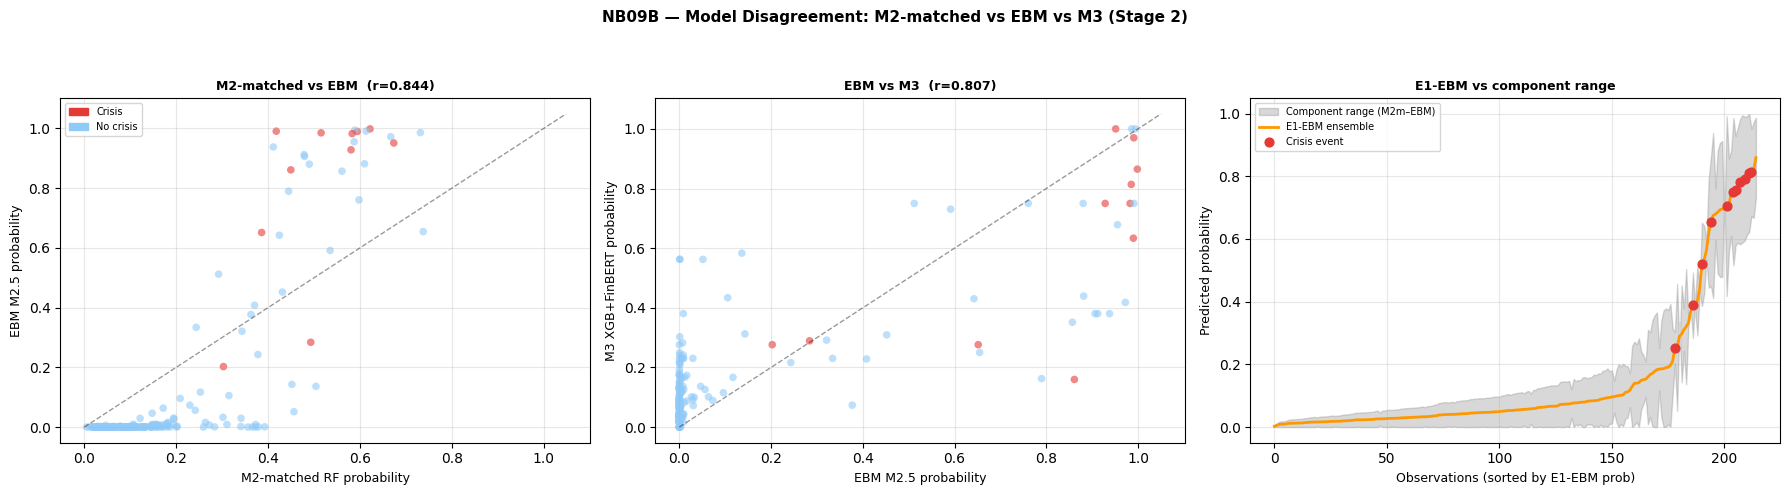

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis\nb09b_ensemble_disagreement.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'NB09B — Model Disagreement: M2-matched vs EBM vs M3 (Stage 2)',
    fontweight='bold', fontsize=11
)

crisis_col = combined[TARGET].map({0: '#90CAF9', 1: '#E53935'})

# Panel 1: M2-matched vs EBM scatter
ax = axes[0]
ax.scatter(combined['prob_m2m'], combined['prob_ebm'],
           c=crisis_col, alpha=0.6, s=30, edgecolors='none')
lim = max(combined['prob_m2m'].max(), combined['prob_ebm'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', alpha=0.4, linewidth=1)
ax.set_xlabel('M2-matched RF probability', fontsize=9)
ax.set_ylabel('EBM M2.5 probability', fontsize=9)
ax.set_title(f'M2-matched vs EBM  (r={corr_m2m_ebm:.3f})',
             fontweight='bold', fontsize=9)
ax.legend(handles=[
    Patch(color='#E53935', label='Crisis'), Patch(color='#90CAF9', label='No crisis')
], fontsize=7)
ax.grid(True, alpha=0.3)

# Panel 2: EBM vs M3 scatter
ax = axes[1]
ax.scatter(combined['prob_ebm'], combined['prob_m3'],
           c=crisis_col, alpha=0.6, s=30, edgecolors='none')
lim2 = max(combined['prob_ebm'].max(), combined['prob_m3'].max()) * 1.05
ax.plot([0, lim2], [0, lim2], 'k--', alpha=0.4, linewidth=1)
ax.set_xlabel('EBM M2.5 probability', fontsize=9)
ax.set_ylabel('M3 XGB+FinBERT probability', fontsize=9)
ax.set_title(f'EBM vs M3  (r={corr_ebm_m3:.3f})', fontweight='bold', fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 3: E1-EBM ensemble vs component range
ax = axes[2]
sorted_idx = combined['prob_e1_ebm'].argsort().values
x = np.arange(len(sorted_idx))
ax.fill_between(x,
    combined['prob_m2m'].values[sorted_idx],
    combined['prob_ebm'].values[sorted_idx],
    alpha=0.3, color='grey', label='Component range (M2m–EBM)')
ax.plot(x, combined['prob_e1_ebm'].values[sorted_idx],
        color='#FF9800', lw=2, label='E1-EBM ensemble')
crisis_pos = np.where(combined[TARGET].values[sorted_idx] == 1)[0]
ax.scatter(crisis_pos,
           combined['prob_e1_ebm'].values[sorted_idx][crisis_pos],
           color='#E53935', zorder=5, s=40, label='Crisis event')
ax.set_xlabel('Observations (sorted by E1-EBM prob)', fontsize=9)
ax.set_ylabel('Predicted probability', fontsize=9)
ax.set_title('E1-EBM vs component range', fontweight='bold', fontsize=9)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.93])
out_path = FIG_DIR / 'nb09b_ensemble_disagreement.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## Cell 8 — ROC and PR curves: all ensembles vs components

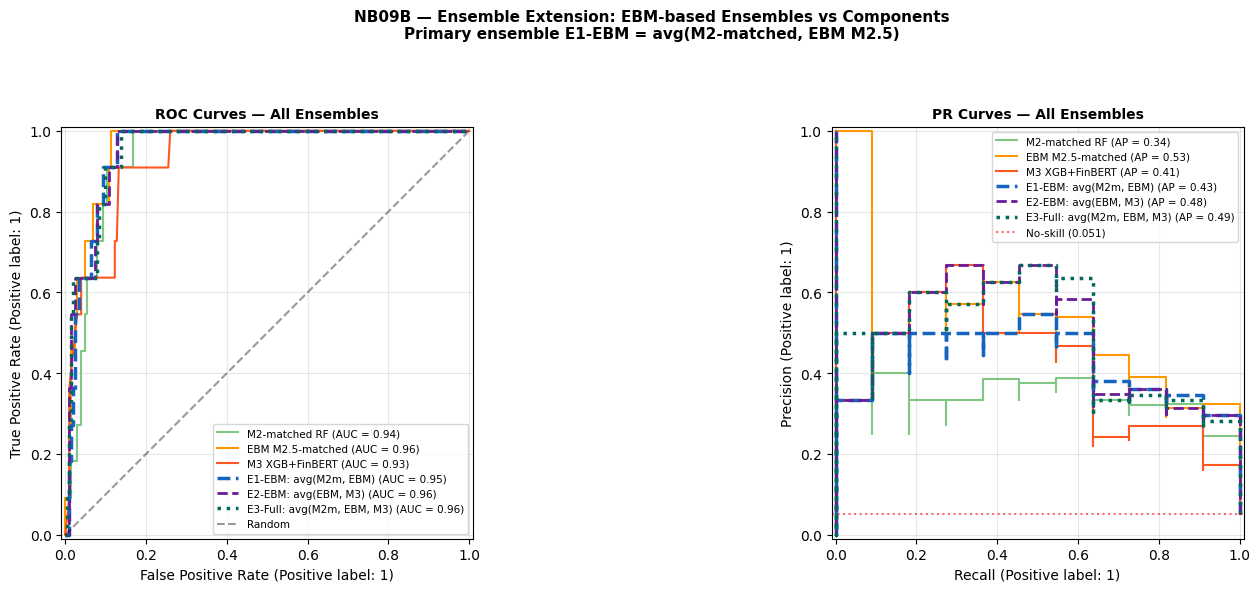

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis\nb09b_ensemble_roc_pr.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'NB09B — Ensemble Extension: EBM-based Ensembles vs Components\n'
    'Primary ensemble E1-EBM = avg(M2-matched, EBM M2.5)',
    fontweight='bold', fontsize=11
)

plot_specs = [
    ('M2-matched RF',              combined['prob_m2m'],    y, '#81C784', '-',  1.5),
    ('EBM M2.5-matched',           combined['prob_ebm'],    y, '#FF9800', '-',  1.5),
    ('M3 XGB+FinBERT',             combined['prob_m3'],     y, '#FF5722', '-',  1.5),
    ('E1-EBM: avg(M2m, EBM)',      combined['prob_e1_ebm'], y, '#1565C0', '--', 2.5),
    ('E2-EBM: avg(EBM, M3)',       combined['prob_e2_ebm'], y, '#6A1B9A', '--', 2.0),
    ('E3-Full: avg(M2m, EBM, M3)', combined['prob_e3_full'],y, '#00695C', ':',  2.5),
]

for name, probs, ys, col, ls, lw in plot_specs:
    RocCurveDisplay.from_predictions(ys, probs, name=name, ax=axes[0],
                                     color=col, linestyle=ls, linewidth=lw)
    PrecisionRecallDisplay.from_predictions(ys, probs, name=name, ax=axes[1],
                                            color=col, linestyle=ls, linewidth=lw)

axes[0].plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
axes[0].set_title('ROC Curves — All Ensembles', fontweight='bold', fontsize=10)
axes[0].legend(loc='lower right', fontsize=7.5)
axes[0].grid(True, alpha=0.3)

axes[1].axhline(y.mean(), color='red', linestyle=':', alpha=0.6,
                label=f'No-skill ({y.mean():.3f})')
axes[1].set_title('PR Curves — All Ensembles', fontweight='bold', fontsize=10)
axes[1].legend(loc='upper right', fontsize=7.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.92])
out_path = FIG_DIR / 'nb09b_ensemble_roc_pr.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## Cell 9 — 2007 Country probability ranking: E1-EBM ensemble

Reproduces the NB09A country ranking with E1-EBM as the primary ensemble.
Tests whether EBM-based ensemble correctly discriminates crisis type.

 2007 COUNTRY PROBABILITY RANKING — E1-EBM ensemble
 Rank   ISO  crisis     M2m     EBM      M3   E1-EBM  Type
----------------------------------------------------------------------------------------------------
    1   FRA       1   0.674   0.951   1.000    0.813  Fundamental ★
    2   ESP       1   0.622   0.999   0.865    0.810  Fundamental ★
    3   USA       0   0.613   0.991   0.750    0.802  Fundamental
    4   IRL       1   0.594   0.990   0.633    0.792  Fundamental ★
    5   SWE       1   0.583   0.983   0.750    0.783  No crisis ★
    6   DNK       1   0.581   0.928   0.750    0.755  Fundamental ★
    7   ITA       1   0.515   0.985   0.814    0.750  Fundamental ★
    8   PRT       1   0.418   0.991   0.970    0.704  Fundamental ★
    9   NOR       0   0.490   0.880   0.750    0.685  No crisis
   10   NLD       1   0.450   0.861   0.160    0.655  Fundamental ★
   11   DEU       1   0.386   0.652   0.276    0.519  Contagion ★
   12   CAN       0   0.292   0.512   0.750    0.4

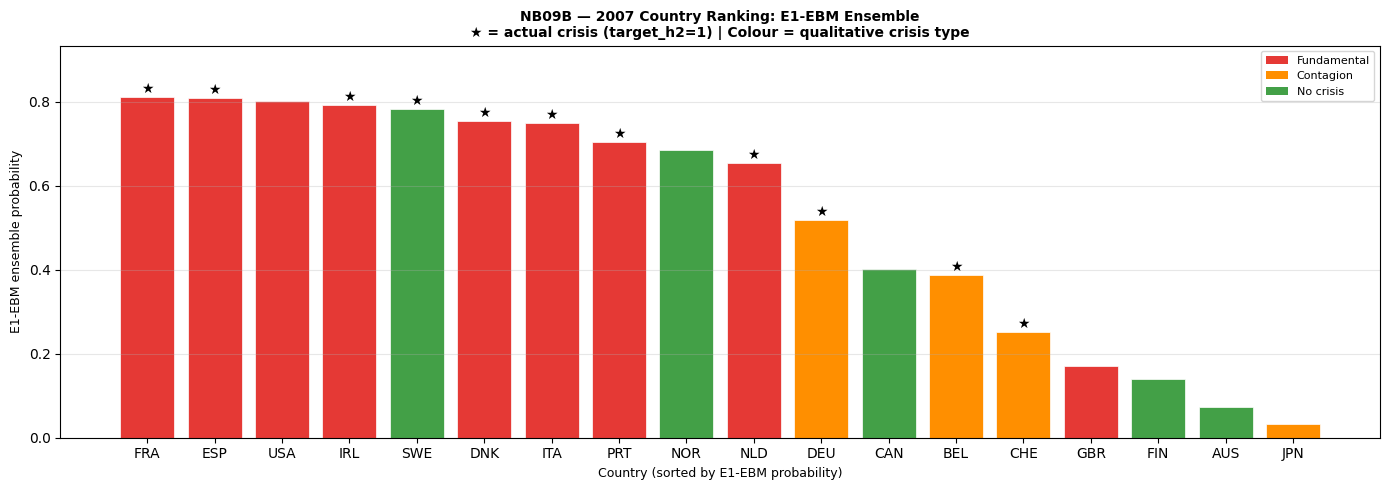

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis\nb09b_2007_country_ranking.png


In [9]:
CRISIS_TYPE_2007 = {
    'USA': ('Fundamental', 'Credit boom, subprime origination, securitisation'),
    'GBR': ('Fundamental', 'Credit boom, wholesale funding dependence (Northern Rock)'),
    'IRL': ('Fundamental', 'Credit boom, property bubble, bank overleverage'),
    'DEU': ('Contagion',   'Landesbanken exposure to US ABS; limited domestic imbalance'),
    'FRA': ('Fundamental', 'Credit expansion, cross-border wholesale exposure'),
    'BEL': ('Contagion',   'Dexia/Fortis cross-border exposure; limited domestic boom'),
    'NLD': ('Fundamental', 'Credit and housing boom, cross-border bank expansion'),
    'CHE': ('Contagion',   'UBS ABS exposure; Swiss domestic fundamentals sound'),
    'ESP': ('Fundamental', 'Construction and credit boom; onset delayed to 2012'),
    'ITA': ('Fundamental', 'Slow growth, sovereign-bank nexus; partial contagion'),
    'PRT': ('Fundamental', 'External imbalance, sovereign-bank nexus; onset 2008'),
    'AUS': ('No crisis',   'Sound macro fundamentals; no systemic event'),
    'CAN': ('No crisis',   'Conservative bank regulation; no systemic event'),
    'JPN': ('Contagion',   'Residual balance sheet weakness; GFC amplified existing stress'),
    'NOR': ('No crisis',   'Oil-driven fiscal surplus; limited exposure'),
    'SWE': ('No crisis',   'Strong bank capital; limited subprime exposure'),
    'DNK': ('Fundamental', 'Property and credit boom; small bank failures 2008'),
    'FIN': ('No crisis',   'Post-1991 restructured banking sector; resilient'),
}

df_2007 = combined[combined['year'] == 2007][
    ['iso', TARGET, 'prob_m2m', 'prob_ebm', 'prob_m3', 'prob_e1_ebm']
].copy().sort_values('prob_e1_ebm', ascending=False).reset_index(drop=True)

df_2007['rank']        = df_2007.index + 1
df_2007['crisis_type'] = df_2007['iso'].map(lambda x: CRISIS_TYPE_2007.get(x, ('Unknown',''))[0])

print('=' * 100)
print(' 2007 COUNTRY PROBABILITY RANKING — E1-EBM ensemble')
print('=' * 100)
print(f' {"Rank":>4}  {"ISO":>4}  {"crisis":>6}  {"M2m":>6}  {"EBM":>6}  {"M3":>6}  {"E1-EBM":>7}  {"Type"}')
print('-' * 100)
for _, r in df_2007.iterrows():
    flag = ' ★' if r[TARGET] == 1 else ''
    print(f' {int(r["rank"]):>4}  {r.iso:>4}  {int(r[TARGET]):>6}  '
          f'{r.prob_m2m:>6.3f}  {r.prob_ebm:>6.3f}  {r.prob_m3:>6.3f}  '
          f'{r.prob_e1_ebm:>7.3f}  {r.crisis_type}{flag}')
print('=' * 100)
print()

print('Mean E1-EBM probability by crisis type:')
print(df_2007.groupby('crisis_type')['prob_e1_ebm']
      .agg(['mean','min','max','count']).round(3)
      .sort_values('mean', ascending=False).to_string())

# Plot
type_colours = {'Fundamental': '#E53935', 'Contagion': '#FF8F00',
                'No crisis': '#43A047', 'Unknown': '#9E9E9E'}
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(df_2007['iso'], df_2007['prob_e1_ebm'],
       color=[type_colours.get(t,'#9E9E9E') for t in df_2007['crisis_type']],
       edgecolor='white', linewidth=0.5)
for i, (_, r) in enumerate(df_2007.iterrows()):
    if r[TARGET] == 1:
        ax.text(i, r.prob_e1_ebm + 0.01, '★', ha='center', fontsize=10)
ax.set_xlabel('Country (sorted by E1-EBM probability)', fontsize=9)
ax.set_ylabel('E1-EBM ensemble probability', fontsize=9)
ax.set_title('NB09B — 2007 Country Ranking: E1-EBM Ensemble\n'
             '★ = actual crisis (target_h2=1) | Colour = qualitative crisis type',
             fontweight='bold', fontsize=10)
legend_elements = [Patch(facecolor=c, label=t)
                   for t, c in type_colours.items() if t != 'Unknown']
ax.legend(handles=legend_elements, fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, min(1.05, df_2007['prob_e1_ebm'].max() * 1.15))
plt.tight_layout()
out_path = FIG_DIR / 'nb09b_2007_country_ranking.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## Cell 10 — Completion summary

In [10]:
print('=' * 65)
print(' NB09B — EBM ENSEMBLE EXTENSION COMPLETE')
print('=' * 65)
print()

e1ebm = results_df.set_index('Label').loc['E1-EBM: avg(M2-matched, EBM)']
e1orig = results_df.set_index('Label').loc['E1-Orig: avg(M2m, M3) [NB09A ref]']

print('PRIMARY RESULT — E1-EBM vs NB09A reference E1-Original:')
print(f'  E1-EBM  AUROC={e1ebm.AUROC:.4f}  AUPRC={e1ebm.AUPRC:.4f}  Brier={e1ebm.Brier:.4f}')
print(f'  E1-Orig AUROC={e1orig.AUROC:.4f}  AUPRC={e1orig.AUPRC:.4f}  Brier={e1orig.Brier:.4f}')
print(f'  AUPRC delta (E1-EBM − E1-Orig): {e1ebm.AUPRC - e1orig.AUPRC:+.4f}')
print()
print('CHAPTER 4 FRAMING:')
print('  Replacing M3 with EBM in the ensemble is motivated by:')
print('  (1) EBM outperforms M3 as a single model on AUROC and AUPRC')
print('  (2) EBM provides native interpretability — ensemble remains partly transparent')
print('  (3) Disagreement analysis shows M2-matched and EBM diverge at crisis events')
print('      — precisely the condition where averaging adds most value')
print()
print('Figures produced:')
for fname in ['nb09b_ensemble_disagreement.png', 'nb09b_ensemble_roc_pr.png',
              'nb09b_2007_country_ranking.png']:
    p = FIG_DIR / fname
    print(f'  {"✅" if p.exists() else "❌"}  {fname}')
print()
print('Files saved:')
p = OUT_DIR / 'oos_predictions_ensemble_ebm.csv'
print(f'  {"✅" if p.exists() else "❌"}  oos_predictions_ensemble_ebm.csv')
print()
print('Pipeline complete. Proceed to Chapter 4 write-up.')

 NB09B — EBM ENSEMBLE EXTENSION COMPLETE

PRIMARY RESULT — E1-EBM vs NB09A reference E1-Original:
  E1-EBM  AUROC=0.9545  AUPRC=0.4329  Brier=0.0557
  E1-Orig AUROC=0.9430  AUPRC=0.4396  Brier=0.0566
  AUPRC delta (E1-EBM − E1-Orig): -0.0067

CHAPTER 4 FRAMING:
  Replacing M3 with EBM in the ensemble is motivated by:
  (1) EBM outperforms M3 as a single model on AUROC and AUPRC
  (2) EBM provides native interpretability — ensemble remains partly transparent
  (3) Disagreement analysis shows M2-matched and EBM diverge at crisis events
      — precisely the condition where averaging adds most value

Figures produced:
  ✅  nb09b_ensemble_disagreement.png
  ✅  nb09b_ensemble_roc_pr.png
  ✅  nb09b_2007_country_ranking.png

Files saved:
  ✅  oos_predictions_ensemble_ebm.csv

Pipeline complete. Proceed to Chapter 4 write-up.
